In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

year = 2023

final_df = pd.read_csv("../../data/07_portfolios_metadata/complete_metadata.csv")
cols_to_keep = ["Ticker", "Country", "Sector", "Industry", "portfolio"]
final_df_cols = cols_to_keep + [x for x in final_df.columns if str(year) in x]
final_df = final_df[final_df["year"]==year][final_df_cols]

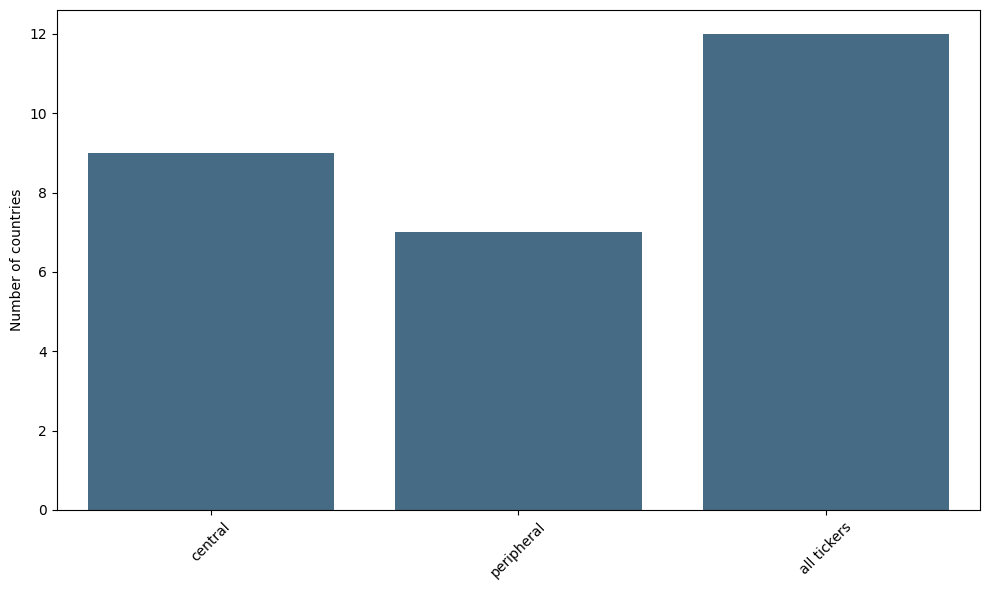

In [2]:
portfolios = final_df["portfolio"].unique()
temp = pd.DataFrame(columns=["n_countries"], index=portfolios)

for i in range(len(portfolios)):
    temp.loc[portfolios[i]] = final_df[final_df["portfolio"]==portfolios[i]]["Country"].nunique()
temp.loc["all tickers"] = final_df["Country"].nunique()

plot_df = temp.reset_index().rename(
    columns={"index": "portfolio"}
)

fig = plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="portfolio",
    y="n_countries",
    color="#3A6F8F"
)

plt.xticks(rotation=45)
plt.xlabel("")
plt.ylabel("Number of countries")
plt.tight_layout()

out_dir = "../../figures"
dpi = 300
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

filename = f"country_barplot_{year}.png"
fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

plt.show()

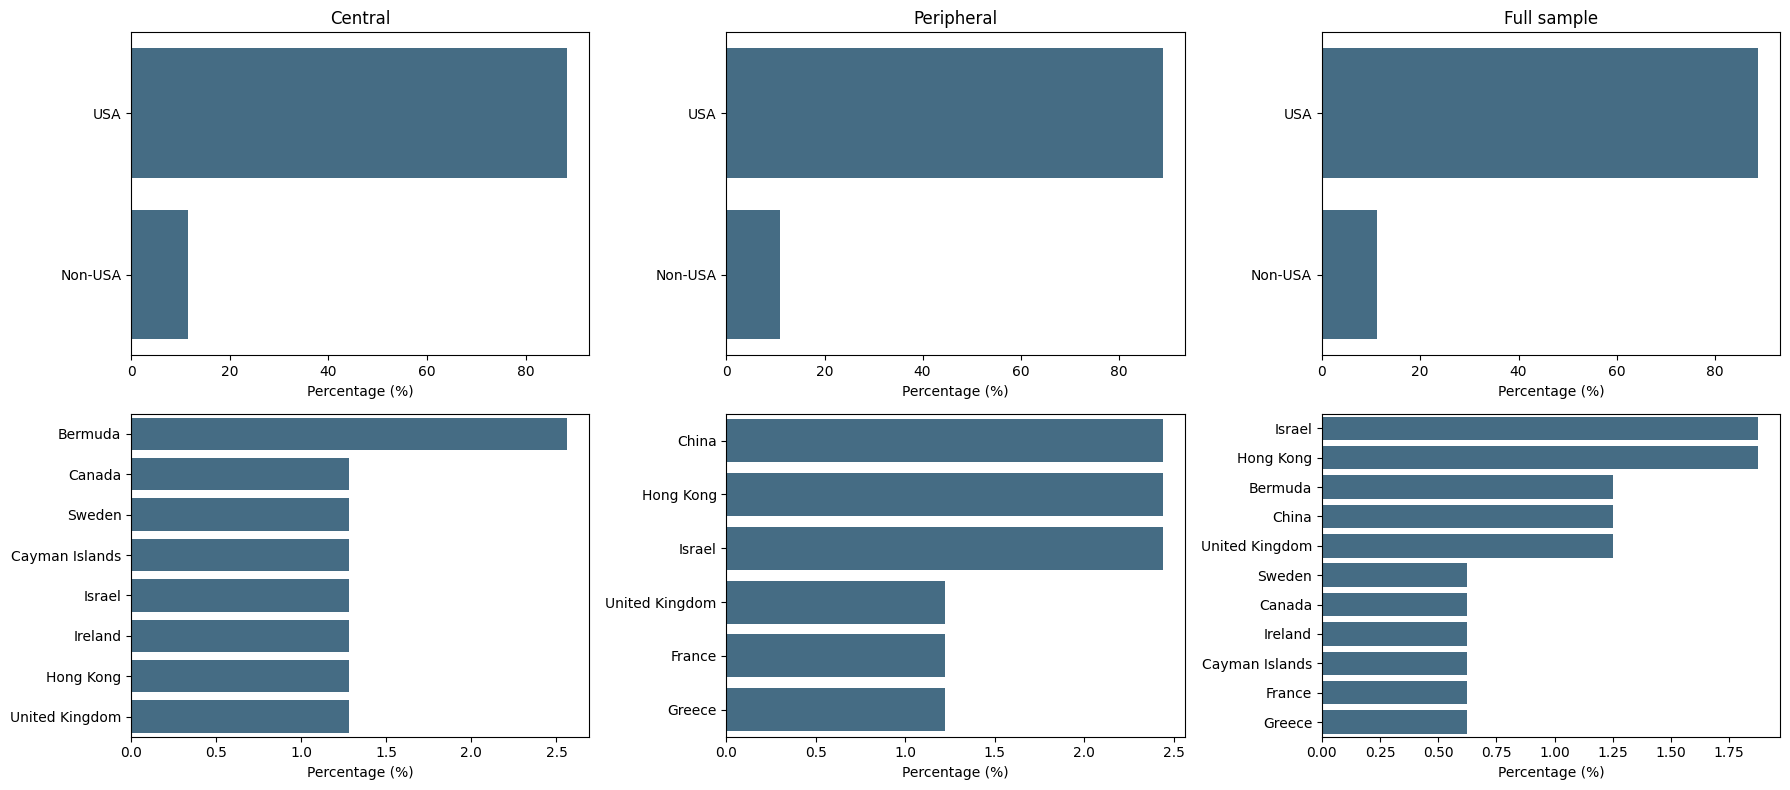

In [3]:
portfolios = final_df["portfolio"].unique()
plots = list(portfolios) + ["Full sample"]

n_cols = 3
n_rows = int(np.ceil(len(plots) / n_cols)) * 2  # dobra as linhas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.reshape(n_rows, n_cols)

for i, port in enumerate(plots):

    row_block = (i // n_cols) * 2
    col = i % n_cols

    ax_top = axes[row_block, col]
    ax_bottom = axes[row_block + 1, col]

    if port == "Full sample":
        data = final_df.copy()
        title = "Full sample"
    else:
        data = final_df[final_df["portfolio"] == port].copy()
        title = port.capitalize()

    # ---------- TOP: USA vs Non-USA ----------
    usa_pct = (data["Country"] == "USA").mean() * 100
    non_usa_pct = 100 - usa_pct

    summary = pd.DataFrame({
        "Category": ["USA", "Non-USA"],
        "Percentage": [usa_pct, non_usa_pct]
    })

    sns.barplot(
        data=summary,
        y="Category",
        x="Percentage",
        ax=ax_top,
        color="#3A6F8F"
    )

    ax_top.set_title(title)
    ax_top.set_xlabel("Percentage (%)")
    ax_top.set_ylabel("")

    # ---------- BOTTOM: Non-USA breakdown ----------
    non_usa_detail = (
        data.loc[data["Country"] != "USA", "Country"]
        .value_counts(normalize=True)
        .mul(non_usa_pct)
        .reset_index()
    )
    non_usa_detail.columns = ["Category", "Percentage"]

    sns.barplot(
        data=non_usa_detail,
        y="Category",
        x="Percentage",
        ax=ax_bottom,
        color="#3A6F8F"
    )

    ax_bottom.set_xlabel("Percentage (%)")
    ax_bottom.set_ylabel("")

# Desligar eixos vazios
for ax in axes.flatten():
    if not ax.has_data():
        ax.axis("off")

plt.tight_layout()

out_dir = "../../figures"
dpi = 300
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

filename = f"country_barplot_det_{year}.png"
fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

plt.show()

## Sector

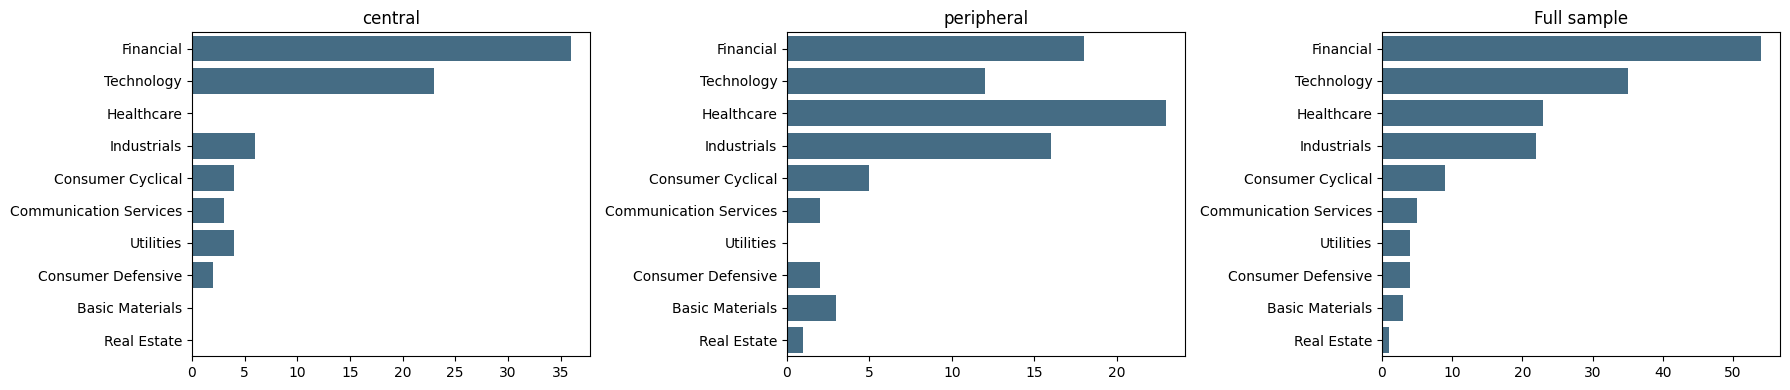

In [4]:
portfolios = final_df["portfolio"].unique()
plots = list(portfolios) + ["Full sample"]

n_cols = 3
n_rows = int(np.ceil(len(plots) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, port in zip(axes, plots):
    if port == "Full sample":
        data = final_df
        title = "Full sample"
    else:
        data = final_df[final_df["portfolio"] == port]
        title = port

    sns.countplot(
        data=data,
        y="Sector",
        order=final_df["Sector"].value_counts().index,
        ax=ax,
        color="#3A6F8F"
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(plots):]:
    ax.axis("off")

plt.tight_layout()

out_dir = "../../figures"
dpi = 300
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

filename = f"sector_barplot_{year}.png"
fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

plt.show()

## Industry

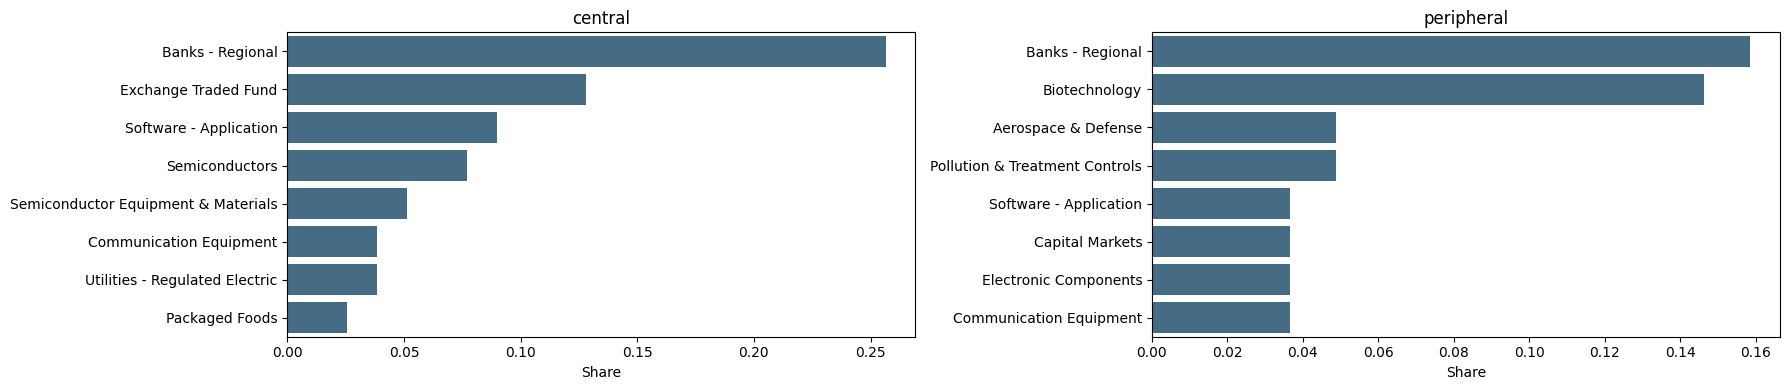

In [5]:
top_n = 8
portfolios = final_df["portfolio"].unique()

n_cols = 2
n_rows = int(np.ceil(len(portfolios) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, port in zip(axes, portfolios):
    data = (
        final_df[final_df["portfolio"] == port]["Industry"]
        .value_counts(normalize=True)
        .head(top_n)
        .reset_index()
    )
    data.columns = ["Industry", "share"]

    sns.barplot(
        data=data,
        y="Industry",
        x="share",
        ax=ax,
        color="#3A6F8F"
    )

    ax.set_title(port)
    ax.set_xlabel("Share")
    ax.set_ylabel("")

# remove eixos vazios
for ax in axes[len(portfolios):]:
    ax.axis("off")

plt.tight_layout()

out_dir = "../../figures"
dpi = 300
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

filename = f"industry_barplot_{year}.png"
fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

plt.show()

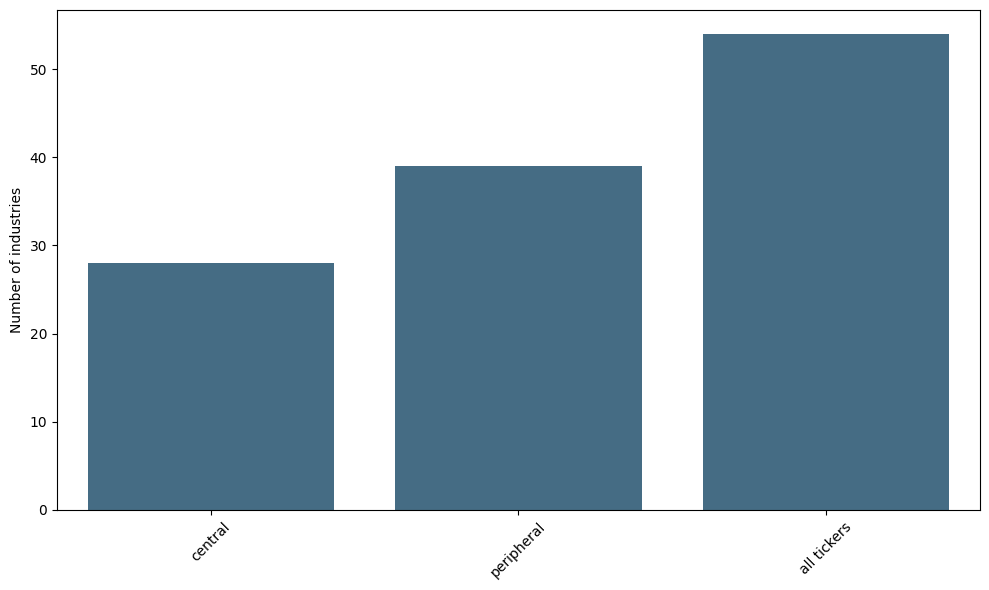

In [6]:
portfolios = final_df["portfolio"].unique()
temp = pd.DataFrame(columns=["n_industries"], index=portfolios)

for i in range(len(portfolios)):
    temp.loc[portfolios[i]] = final_df[final_df["portfolio"]==portfolios[i]]["Industry"].nunique()
temp.loc["all tickers"] = final_df["Industry"].nunique()

plot_df = temp.reset_index().rename(
    columns={"index": "portfolio"}
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="portfolio",
    y="n_industries",
    color="#3A6F8F"
)

plt.xticks(rotation=45)
plt.xlabel("")
plt.ylabel("Number of industries")
plt.tight_layout()

out_dir = "../../figures"
dpi = 300
out_path = Path(out_dir)
out_path.mkdir(parents=True, exist_ok=True)

filename = f"n_industries_barplot_{year}.png"
fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

plt.show()

## Função de boxplots

In [7]:
def plot_metric_boxplots(
    df,
    metric,
    portfolio_col="portfolio",
    log_scale=False,
    figsize=(15, 5),
    metric_name=None,
    showfliers=False,
    save=True,
    out_dir="../../figures",
    dpi=300
):
    cut_col = metric + "_cut"
    metric_label = metric_name if metric_name else metric
    title_left = metric_label + " by Portfolios"
    title_right = metric_label + " by Quantile Cuts"

    # Presentation font sizes
    TITLE_SIZE = 18
    LABEL_SIZE = 16
    TICK_SIZE = 14

    fig, ax = plt.subplots(1, 2, figsize=figsize)

    # Log scale
    if log_scale:
        ax[0].set_yscale("log")
        ax[1].set_yscale("log")
        metric_label = metric_label + " (Log Scale)"

    # Left plot
    sns.boxplot(
        data=df,
        x=portfolio_col,
        y=metric,
        showfliers=showfliers,
        ax=ax[0],
        color="#3A6F8F",
        linewidth=1.5
    )
    ax[0].set_title(title_left, fontsize=TITLE_SIZE, fontweight="bold")
    ax[0].set_xlabel("")
    ax[0].set_ylabel(metric_label, fontsize=LABEL_SIZE, fontweight="bold")
    ax[0].tick_params(axis="x", rotation=45, labelsize=TICK_SIZE, width=1.5)
    ax[0].tick_params(axis="y", labelsize=TICK_SIZE, width=1.5)
    ax[0].grid(axis="y", linestyle="--", alpha=0.4)

    # Right plot
    sns.boxplot(
        data=df,
        x=cut_col,
        y=metric,
        showfliers=showfliers,
        ax=ax[1],
        color="#3A6F8F",
        linewidth=1.5
    )
    ax[1].set_title(title_right, fontsize=TITLE_SIZE, fontweight="bold")
    ax[1].set_xlabel("")
    ax[1].set_ylabel(metric_label, fontsize=LABEL_SIZE, fontweight="bold")
    ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)
    ax[1].tick_params(axis="x", rotation=45, width=1.5)
    ax[1].tick_params(axis="y", labelsize=TICK_SIZE, width=1.5)
    ax[1].grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()

    # Save figure
    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        filename = f"{metric}_boxplot_{year}.png"
        fig.savefig(out_path / filename, dpi=dpi, bbox_inches="tight")

    plt.show()

## Market Cap

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


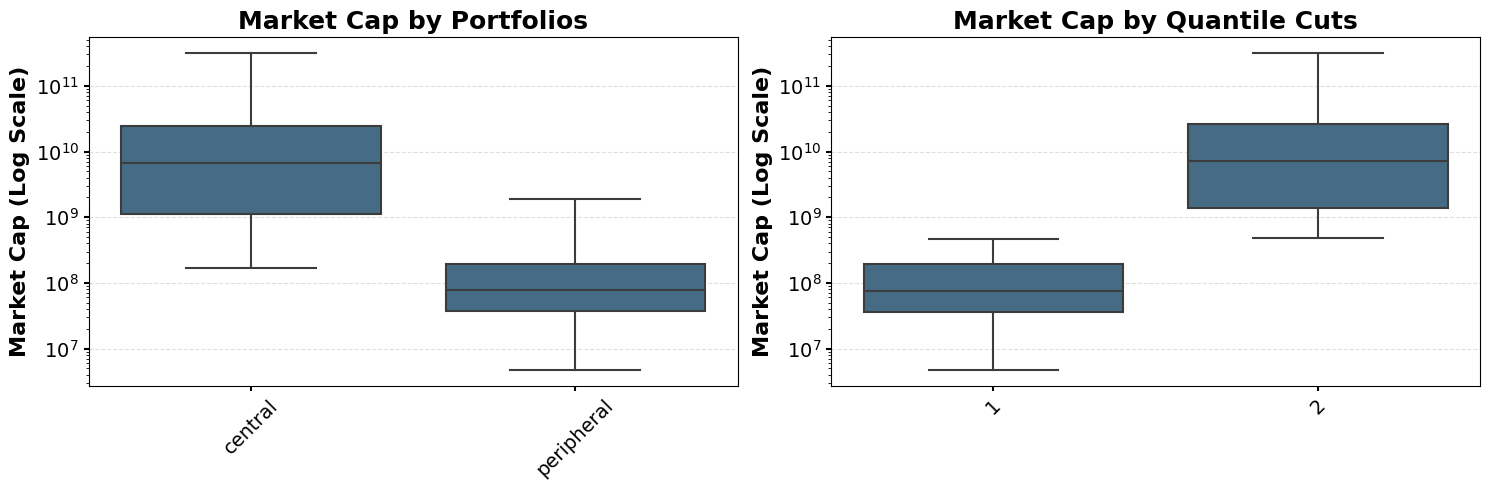

In [8]:
plot_metric_boxplots(
    df=final_df,
    metric=f"mcap_{year}",
    log_scale=True,
    metric_name="Market Cap"
)

## Price to Earnings

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


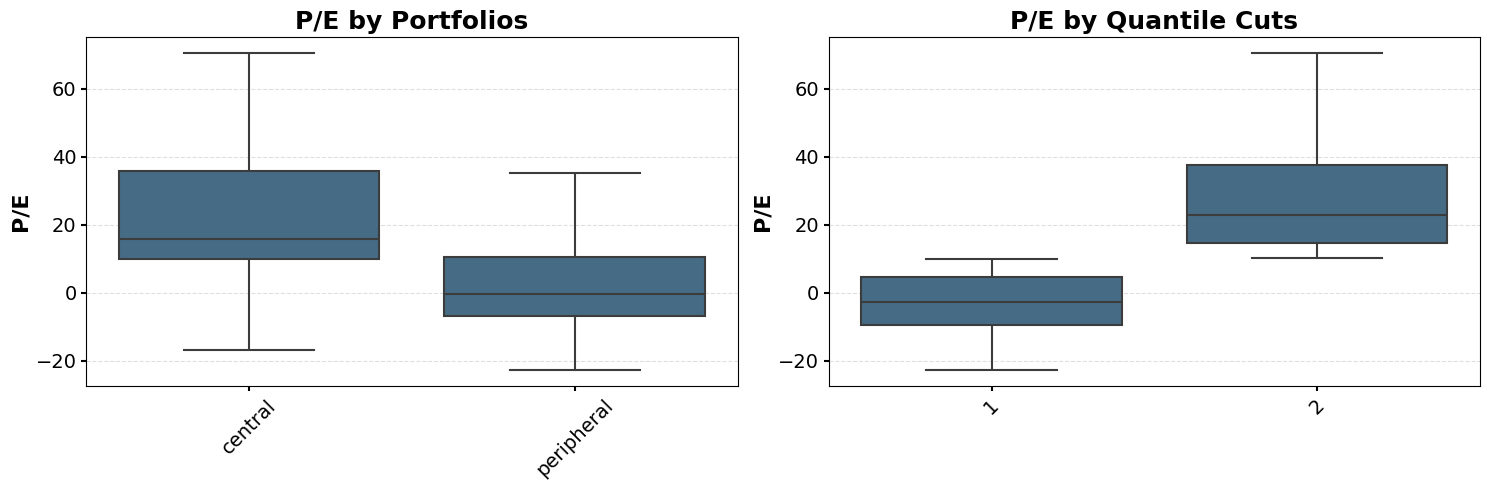

In [9]:
plot_metric_boxplots(
    df=final_df,
    metric=f"pe_{year}",
    log_scale=False,
    metric_name="P/E"
)

### Piotroski Score

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


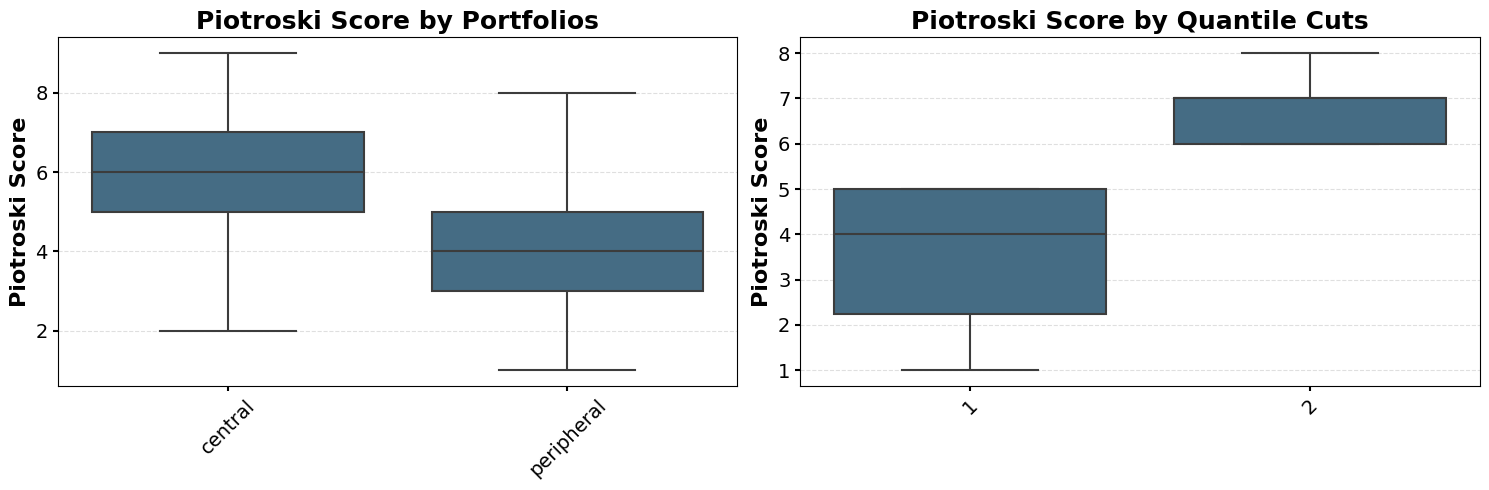

In [10]:
plot_metric_boxplots(
    df=final_df,
    metric=f"pscore_{year}",
    log_scale=False,
    metric_name="Piotroski Score"
)

### Altman Z Score

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


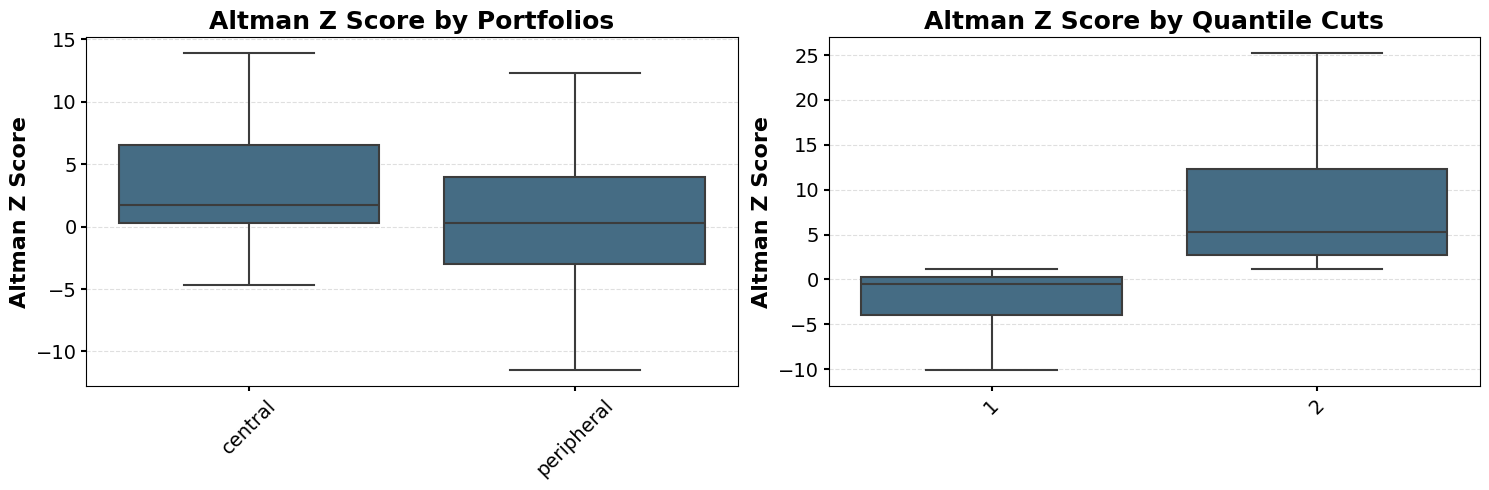

In [11]:
plot_metric_boxplots(
    df=final_df,
    metric=f"azscore_{year}",
    log_scale=False,
    metric_name="Altman Z Score"
)

### Free Cash Flow Yield

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


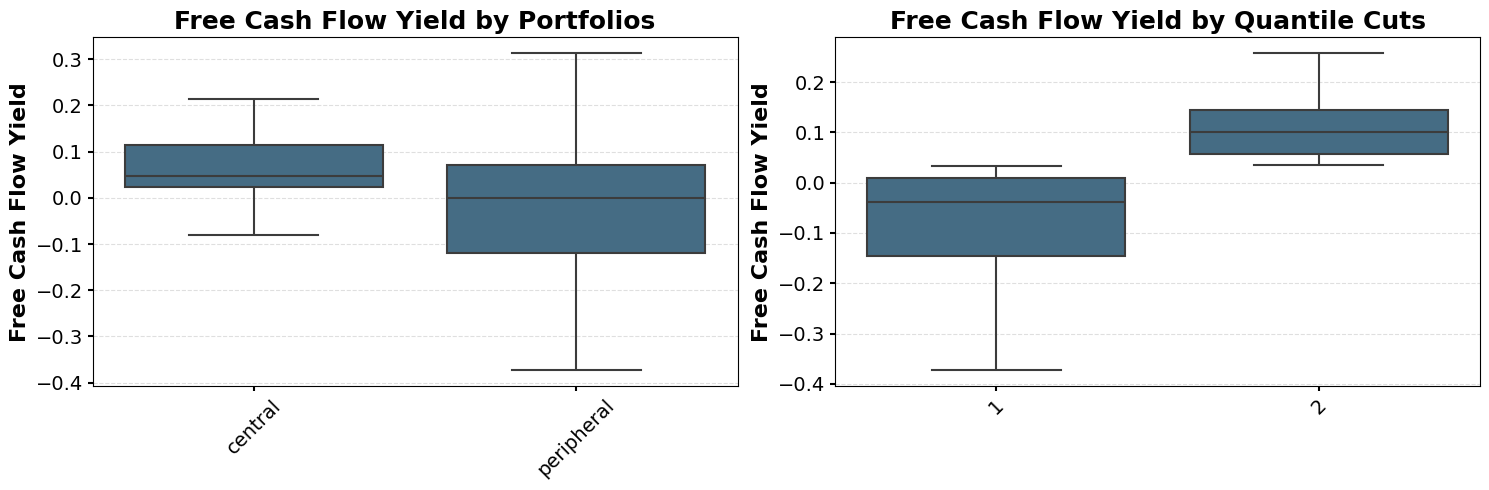

In [12]:
plot_metric_boxplots(
    df=final_df,
    metric=f"fcfyield_{year}",
    log_scale=False,
    metric_name="Free Cash Flow Yield"
)

### Return on Invested Capital

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


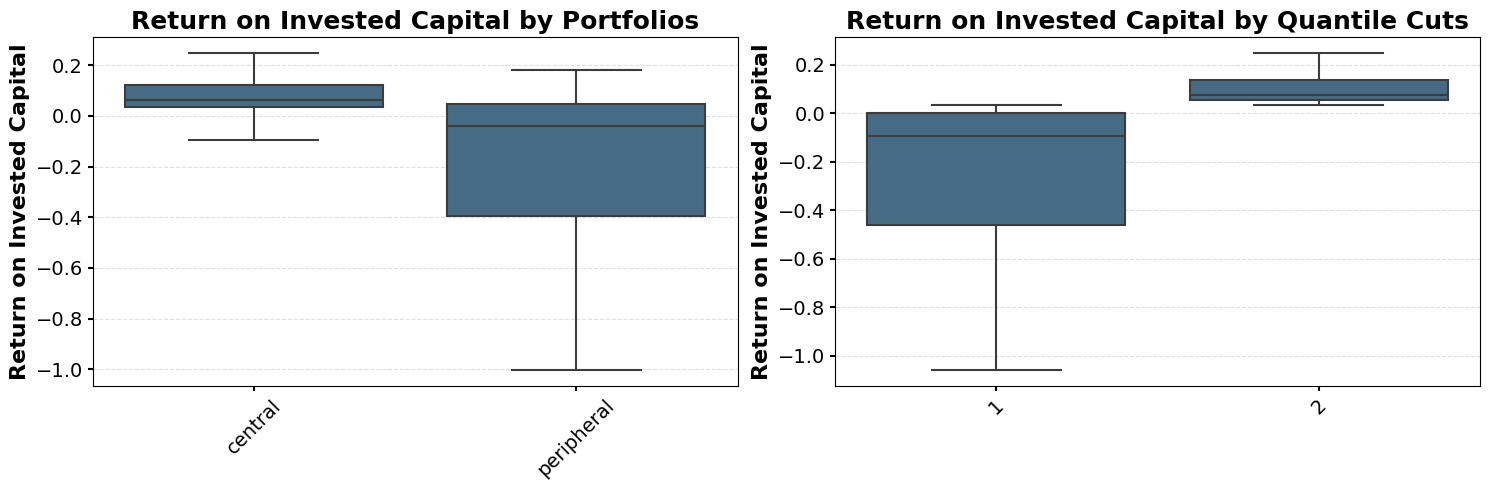

In [13]:
plot_metric_boxplots(
    df=final_df,
    metric=f"roic_{year}",
    log_scale=False,
    metric_name="Return on Invested Capital"
)

### Revenue Growth

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


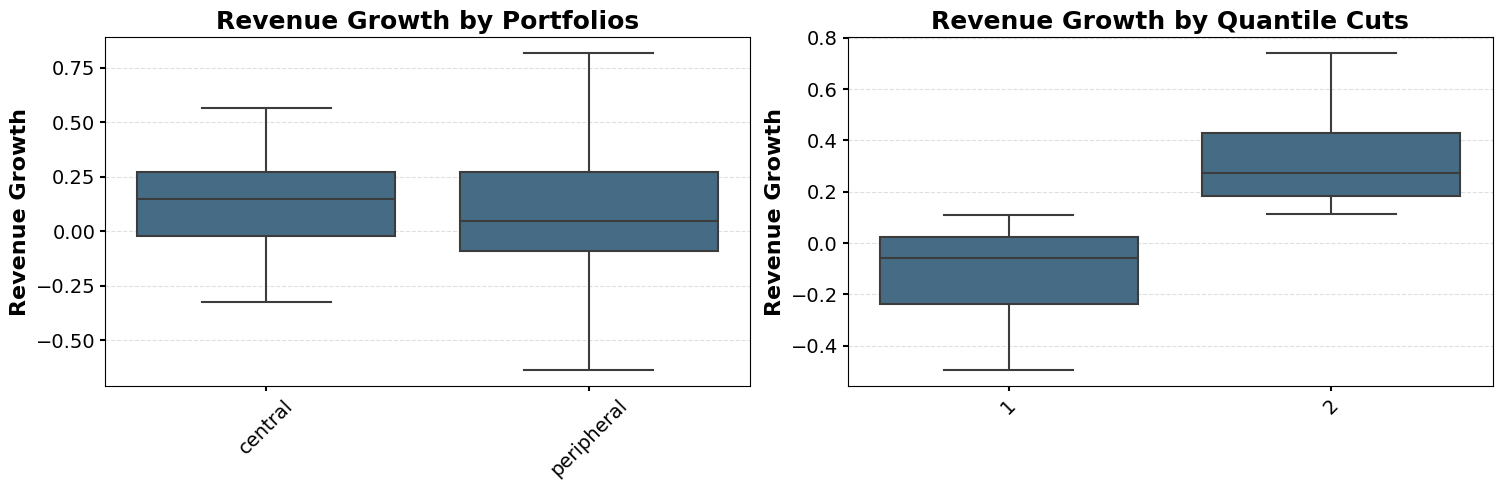

In [14]:
plot_metric_boxplots(
    df=final_df,
    metric=f"rg_{year}",
    log_scale=False,
    metric_name="Revenue Growth"
)

### Net Debt / EBITDA

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


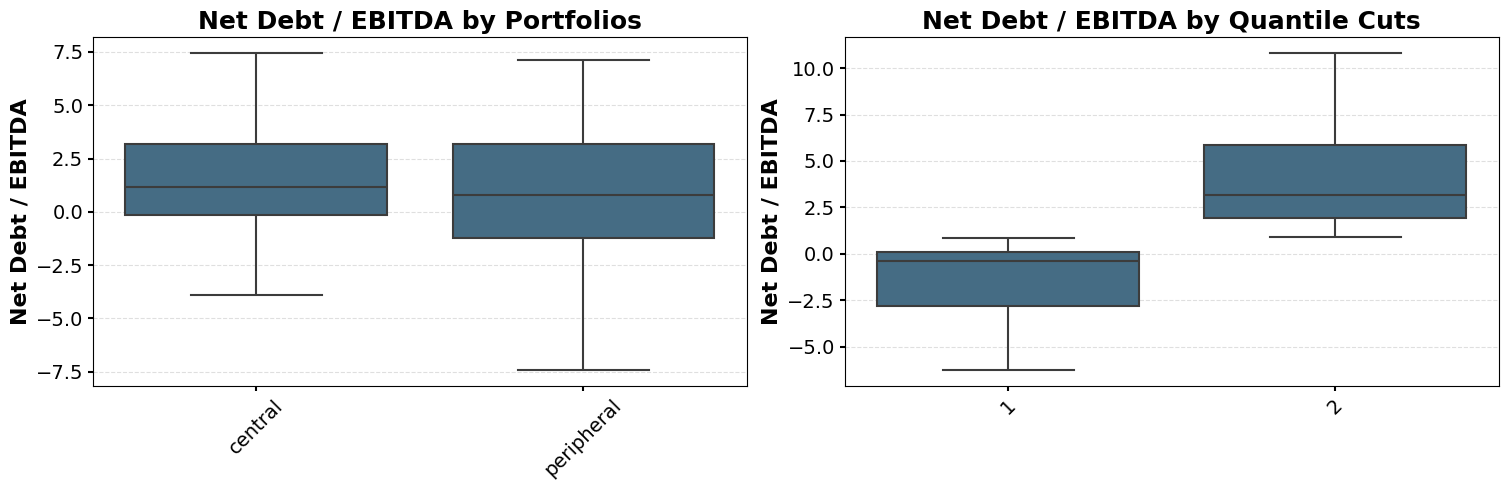

In [15]:
plot_metric_boxplots(
    df=final_df,
    metric=f"ndebitda_{year}",
    log_scale=False,
    metric_name="Net Debt / EBITDA"
)

### Gross Profit Margin

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


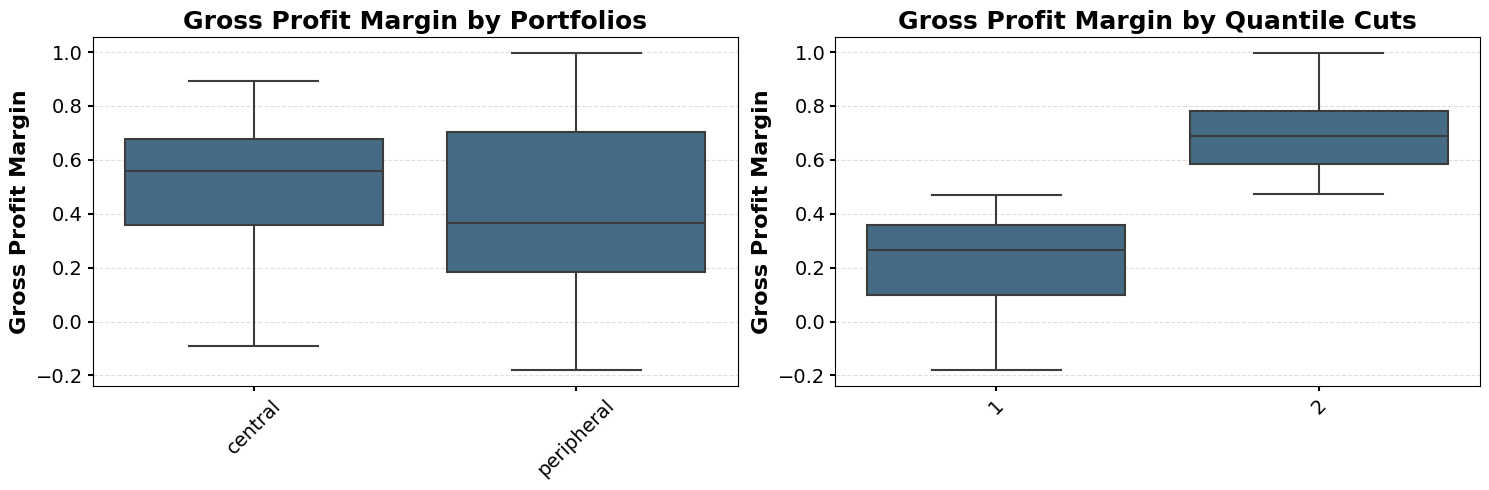

In [16]:
plot_metric_boxplots(
    df=final_df,
    metric=f"gpm_{year}",
    log_scale=False,
    metric_name="Gross Profit Margin"
)

### EPS Diluted Growth

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


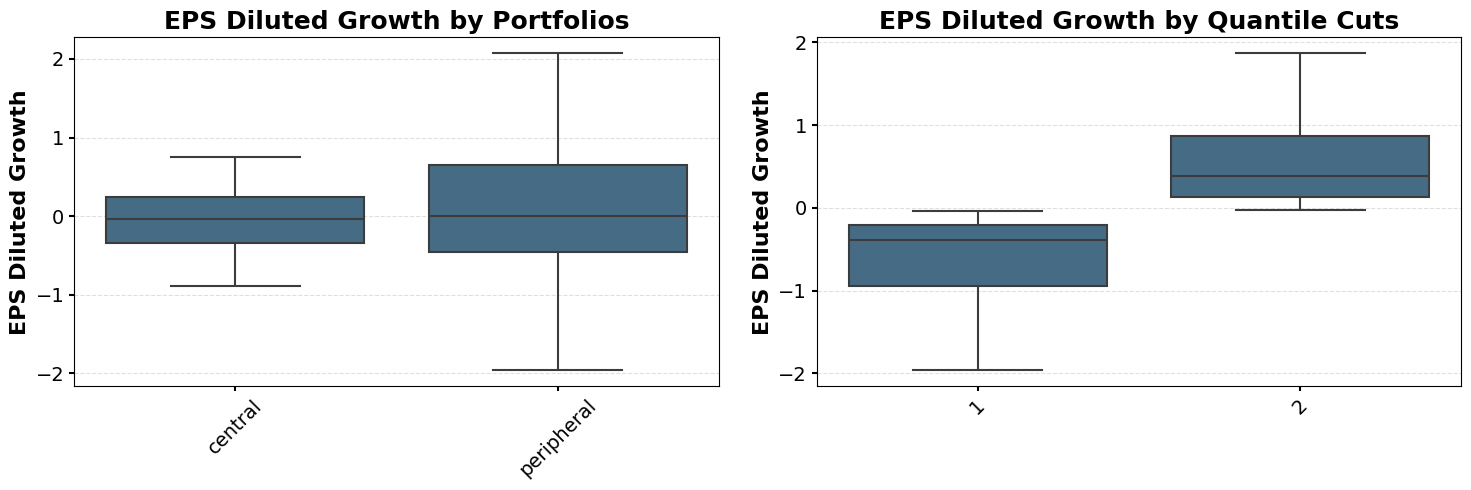

In [17]:
plot_metric_boxplots(
    df=final_df,
    metric=f"epsdg_{year}",
    log_scale=False,
    metric_name="EPS Diluted Growth"
)

### Beta

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


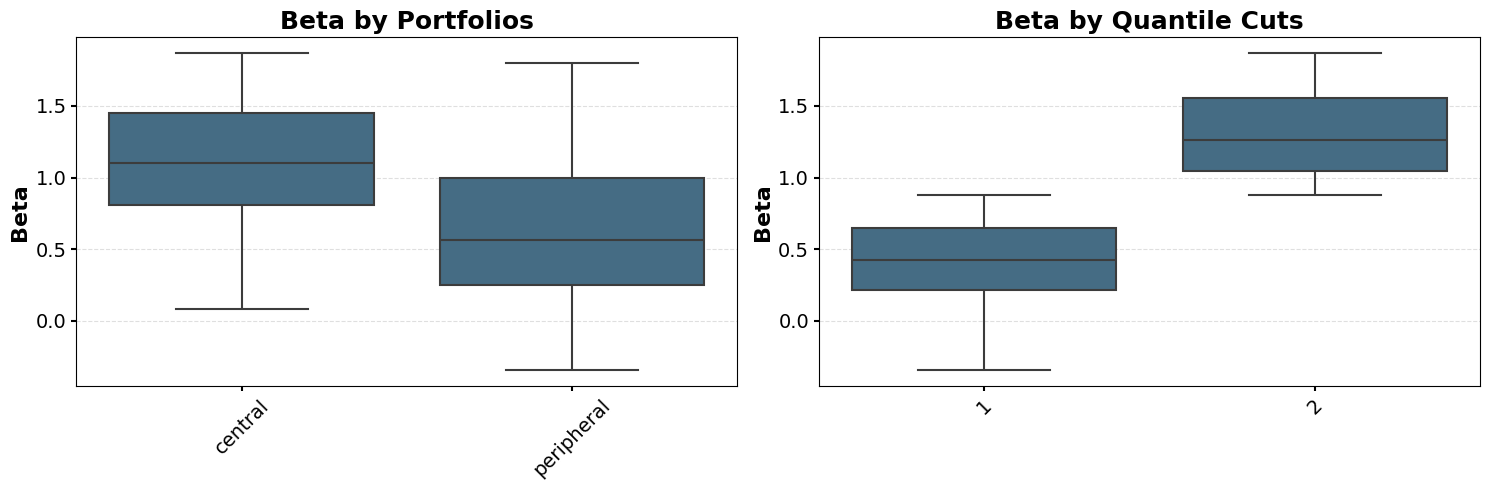

In [18]:
plot_metric_boxplots(
    df=final_df,
    metric=f"beta_{year}",
    log_scale=False,
    metric_name="Beta"
)

### Momentum 12 months

C:\Users\groque\AppData\Local\Temp\ipykernel_15280\3318383293.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([1, 2, 3, 4, 5, 6], fontsize=TICK_SIZE)


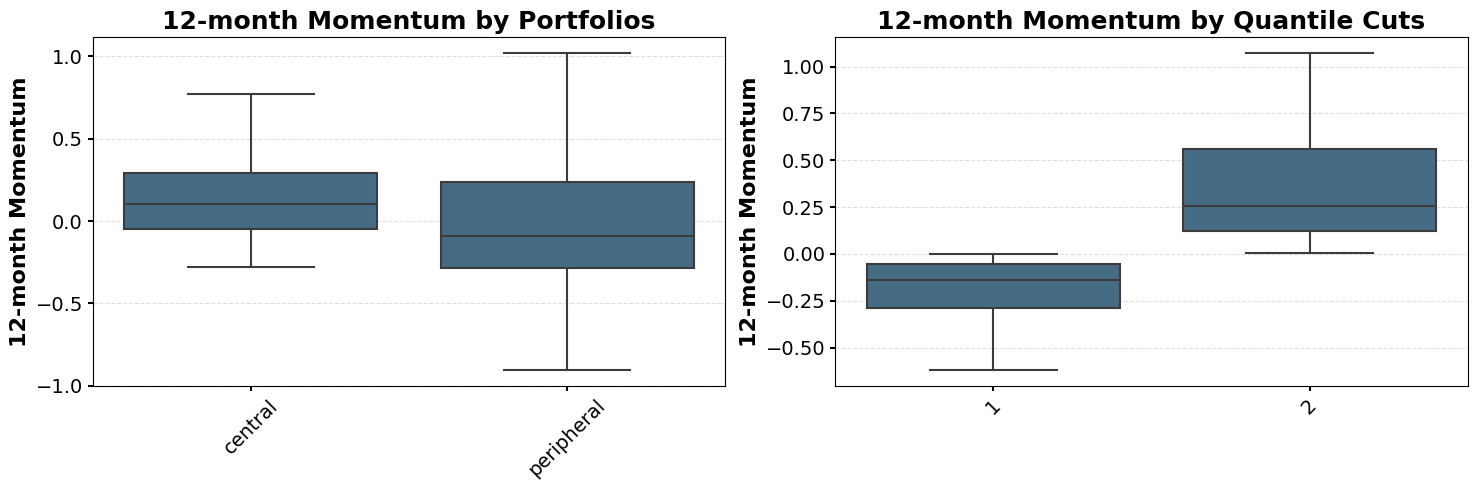

In [19]:
plot_metric_boxplots(
    df=final_df,
    metric=f"momentum12mo_{year}",
    log_scale=False,
    metric_name="12-month Momentum"
)